# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

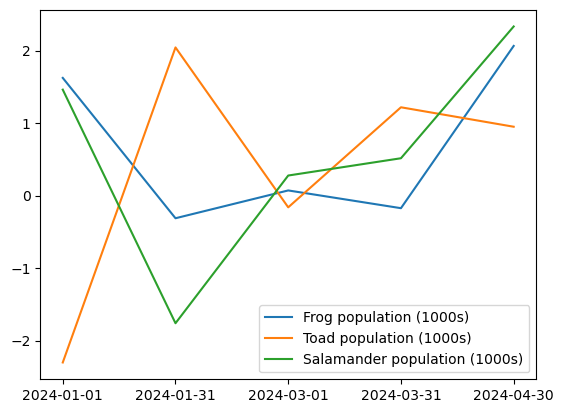

In [3]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

Pros: it has some descriptors about what eadh population is from the legend, each graph is a different color
Cons: -2000 population is not realistic, needs axes labels and a title, colors are distracting and could be used to illustrate a specific point of the graph

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

In [4]:
# Import libraries
import scipy.stats as stats

In [5]:
# Load data
diabetes_indicators = pd.read_csv('Modified_Datasets/diabetes_indicators.csv')
obesity = pd.read_csv('Modified_Datasets/obesity.csv')
cervical_cancer = pd.read_csv('Modified_Datasets/cervical_cancer.csv')

In [6]:
diabetes_indicators.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [7]:
obesity.columns

Index(['Age (yrs)', 'Height (m)', 'Weight (kg)', 'Vegetables with Meals',
       '# of Main Meals/Day', 'Water/Day', 'Physical Activity',
       'Technology Time', 'Obesity Level', 'BMI', 'Gender_Male',
       'family_history_with_overweight_yes',
       'Frequent Caloric Food Intake_yes', 'Smoker_yes',
       'Calories Monitored_yes', 'Transportation Method_Bike',
       'Transportation Method_Motorbike',
       'Transportation Method_Public_Transportation',
       'Transportation Method_Walking', 'Snacking (Encoded)',
       'Alcohol Frequency (Encoded)'],
      dtype='object')

In [8]:
cervical_cancer.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [9]:
# t-tests

In [10]:
print(stats.ttest_ind(diabetes_indicators['MentHlth'], diabetes_indicators['PhysHlth']))

TtestResult(statistic=np.float64(-47.16665417483906), pvalue=np.float64(0.0), df=np.float64(459560.0))


In [11]:
print(stats.ttest_ind(obesity['Physical Activity'], obesity['BMI']))

TtestResult(statistic=np.float64(-162.7645261853851), pvalue=np.float64(0.0), df=np.float64(4172.0))


In [12]:
print(stats.ttest_ind(cervical_cancer['Citology'], cervical_cancer['Biopsy']))

TtestResult(statistic=np.float64(-1.1505692173048627), pvalue=np.float64(0.25007442025471566), df=np.float64(1668.0))


In [13]:
# Mann Whitney U tests

In [14]:
u_value, p_value = stats.mannwhitneyu(diabetes_indicators['MentHlth'], diabetes_indicators['PhysHlth'])

print(p_value)

0.0


In [15]:
u_value, p_value = stats.mannwhitneyu(obesity['Physical Activity'], obesity['BMI'])

print(p_value)

0.0


In [16]:
u_value, p_value = stats.mannwhitneyu(cervical_cancer['Citology'], cervical_cancer['Biopsy'])

print(p_value)

0.2500070048998424


In [17]:
# ANOVA

In [18]:
result = stats.f_oneway(diabetes_indicators['HighBP'], diabetes_indicators['HighChol'], diabetes_indicators['AnyHealthcare'])

print(result.pvalue)

0.0


In [19]:
result = stats.f_oneway(obesity['Transportation Method_Bike'], obesity['Transportation Method_Public_Transportation'], obesity['Transportation Method_Walking'])

print(result.pvalue)

0.0


In [20]:
result = stats.f_oneway(cervical_cancer['Dx:HPV'], cervical_cancer['Citology'], cervical_cancer['Biopsy'])

print(result.pvalue)

8.880999917857259e-05


In [21]:
# chi-squared

In [22]:
table = pd.crosstab(diabetes_indicators['AnyHealthcare'], diabetes_indicators['PhysHlth'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"p-value: {p:.4f}")

p-value: 0.0002


In [23]:
table = pd.crosstab(obesity['BMI'], obesity['Smoker_yes'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"p-value: {p:.4f}")

p-value: 0.9348


In [24]:
table = pd.crosstab(cervical_cancer['Hormonal Contraceptives'], cervical_cancer['Biopsy'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"p-value: {p:.4f}")

p-value: 0.9264


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

In [25]:
# Generate data
artsnculture = np.linspace(20, 41, 12)
education = np.linspace(76, 55, 12)
health = np.linspace(50, 78, 12)
humanservices = np.linspace(86, 60, 12)
other = np.linspace(50, 25, 12)
x = pd.date_range('2020-01-01', '2025-12-31', periods = 12)

In [26]:
import matplotlib.ticker as mtick

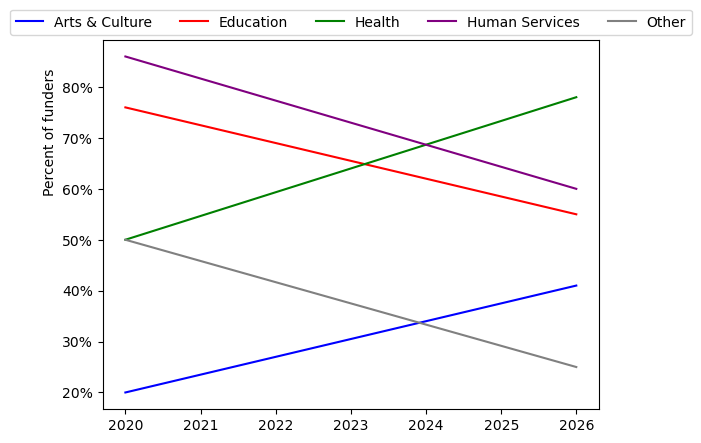

In [27]:
plt.plot(x, artsnculture, c = 'blue', label = 'Arts & Culture')
plt.plot(x, education, c = 'red', label = 'Education')
plt.plot(x, health, c = 'green', label = 'Health')
plt.plot(x, humanservices, c = 'purple', label = 'Human Services')
plt.plot(x, other, c = 'gray', label = 'Other')
plt.legend(loc = 'upper center', ncol = 5, bbox_to_anchor = (0.5, 1.10))
plt.ylabel('Percent of funders')
plt.gca().yaxis.label.set_position((0, 0.75))
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
plt.show()